# **Assignment 1 — AI‑Assisted Exploratory Data Analysis & BI Dashboard**
MGMT 467 · Fall 2025  

**Team Name:** Team 10

**Members (GitHub handles):** ethanquinn5, JackStrabala, Tomas-Turner

**GitHub Repo URL:** https://github.com/Tomas-Turner/Unit1_TheLook_Team10  
**Looker Studio Dashboard (public link):** ☐

> **Scenario:** NYC DOT has asked your team to analyze the public Citi Bike program and recommend strategies to improve bike availability and engagement. You will use BigQuery + Gemini to conduct AI‑assisted EDA and publish an executive dashboard.

## ✅ Submission Checklist (Team → Brightspace)
- [ ] GitHub repository link (source of record)
- [ ] Looker Studio dashboard link
- [ ] This notebook committed to GitHub with prompts and results

### ✅ Submission Checklist (Individual → Brightspace)
- [ ] `Contribution_Reflection.pdf` (with commit/PR evidence + peer eval)

## 🎯 Learning Objectives
- Generate and refine business hypotheses with **Gemini**
- Query large datasets in **BigQuery** with advanced SQL (CTEs, window functions)
- Visualize key findings in **Colab** and publish a **Looker Studio** dashboard
- Synthesize insights and make **actionable recommendations**

## 🧰 Setup
> Run the cells below to connect Colab to Google Cloud & BigQuery.

In [7]:
# Install and import basics (Colab usually has these preinstalled)
# !pip install --quiet google-cloud-bigquery pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt

# Authenticate to Google from Colab
from google.colab import auth  # type: ignore
auth.authenticate_user()

# Set your GCP project ID
PROJECT_ID = "mgmt-467-35946"  # <-- edit this
print("Using project:", PROJECT_ID)

Using project: mgmt-467-35946


In [8]:
# BigQuery magics (%%bigquery) and client
from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)

# Optional: list datasets to verify access
list(client.list_datasets())

## 🧪 Dataset
We will use **Citi Bike Trips**: `bigquery-public-data.new_york_citibike.citibike_trips`  
Feel free to explore additional public datasets if needed.

## 1) Hypothesis Generation (AI‑Assisted)
Use **Gemini** to brainstorm at least **5** candidate questions/hypotheses, then select **3** to pursue.

> **Template Prompt:
**  
> *"You are an analytics co‑pilot. Propose 5 high‑value, testable business questions about the Citi Bike dataset (tripduration, stations, user types, time-of-day/week). Return as bullets with suggested SQL hints."*

> **My Prompt:
**  
> *"You are an analytics co‑pilot. Propose 5 high‑value, testable business questions about the Citi Bike dataset (tripduration, stations, user types, time-of-day/week). Return as bullets with suggested SQL hints. Return business questions that will allow you make a fast, cost-effective analytics pack that (a) surfaces growth opportunities and risks and (b) proposes specific, near-term actions."*

**Selected Hypotheses**

A. What are the peak hours and days of the week for Citi Bike usage, and how does this vary by user type (customer vs. subscriber)?  

B. What are the most popular routes (start station to end station pairs), and how do these routes differ between customer and subscriber users?

C. Which stations have the highest volume of start and end trips, and which ones have the highest imbalances between starts and ends?

# AI 5 Outputs

- **Question 1:** What are the peak hours and days of the week for Citi Bike usage, and how does this vary by user type (customer vs. subscriber)?
  * **SQL Hint:** Use `EXTRACT` to get the hour and day of the week from `starttime`. Group by hour, day of week, and `usertype`.

- **Question 2:** Which stations have the highest volume of start and end trips, and which ones have the highest imbalances between starts and ends?

  * **SQL Hint:** Group by `start_station_name` and `end_station_name` and count the trips. Use a `UNION ALL` or separate queries to analyze starts and ends, and potentially join them to find imbalances.

- **Question 3:** How does trip duration vary by user type, time of day, and day of the week?
  * **SQL Hint:** Calculate the average, median, and distribution of `tripduration` grouped by `usertype`, hour of day, and day of week.

- **Question 4:** What are the most popular routes (start station to end station pairs), and how do these routes differ between customer and subscriber users?
  * **SQL Hint:** Concatenate `start_station_name` and `end_station_name` to create a route identifier. Group by this identifier and `usertype` to count the trips for each route.

- **Question 5:** How has Citi Bike usage changed over time (e.g., monthly or yearly trends) in terms of total trips, average trip duration, and user type distribution?
  * **SQL Hint:** Use `DATE_TRUNC` or `EXTRACT` to group trips by month or year. Calculate aggregate measures like `COUNT(*)`, `AVG(tripduration)`, and counts of each `usertype` within each time period.

## 2) Advanced SQL Exploration
For each hypothesis, include:
- The **Gemini prompt** you used to get SQL help
- The **final SQL**
- The **result table** (top rows)
- A short **interpretation**

> Tip: Use **CTEs** and at least **one window function** across your work.

### Hypothesis A — Prompt Log

Gemini Prompt: This is my Hypothesis A: "What are the peak hours and days of the week for Citi Bike usage, and how does this vary by user type (customer vs. subscriber)?" For the remained of this project, I will be using my bigquery table called new_york_citibike2 that includes two tables, citibike_stations, and citibike_trips. I want to create SQL code so that I can answer my hypothesis A, what would the code be?

In [17]:
# Hypothesis A — SQL (store results in a Pandas DataFrame)
query_hyp_a = r"""
SELECT
    EXTRACT(HOUR FROM starttime) AS peak_hour,
    EXTRACT(DAYOFWEEK FROM starttime) AS peak_day_of_week,
    usertype,
    COUNT(*) AS number_of_trips
FROM
    `mgmt-467-35946.new_york_citibike2.citibike_trips`
WHERE
    EXTRACT(HOUR FROM starttime) IS NOT NULL AND EXTRACT(DAYOFWEEK FROM starttime) IS NOT NULL
GROUP BY
    peak_hour,
    peak_day_of_week,
    usertype
ORDER BY
    number_of_trips DESC
"""

df_hyp_a = client.query(query_hyp_a).to_dataframe()
df_hyp_a.head()

,peak_hour,peak_day_of_week,usertype,number_of_trips
0,18,4,Subscriber,829280
1,18,3,Subscriber,824377
2,8,4,Subscriber,818200
3,17,4,Subscriber,811173
4,17,3,Subscriber,808343


**Interpretation (2–4 sentences):**
The first time that I ran the code, the top numbers were both N/A, so the first interpretation was that there were a lot of null values, so I decided to change that. The second thing we can notice is that the most common hour is 6 p.m., it has the top 2 rankings. We can also see that looking at the 4th and 5th highest ranked hour, 5 pm, we can infer that most people use citibikes during the afternoon, and probably while going home from work. Finally, we can see that the main usertype is subscriber, meaning that these are people that pay subscriptions rather than each individual ride.


---

### Hypothesis B — Prompt Log

Gemini Prompt: Now, I want to find hypothesis B: "What are the most popular routes (start station to end station pairs), and how do these routes differ between customer and subscriber users?" what is the code to find this out? Filter out all the Nulls



In [26]:
# Hypothesis B — SQL
query_hyp_b = r"""
SELECT
    start_station_name,
    end_station_name,
    usertype,
    COUNT(*) AS number_of_trips
FROM
    `mgmt-467-35946.new_york_citibike2.citibike_trips`
WHERE
    start_station_name IS NOT NULL AND start_station_name != '' AND
    end_station_name IS NOT NULL AND end_station_name != '' AND
    usertype IS NOT NULL AND usertype != ''
GROUP BY
    start_station_name,
    end_station_name,
    usertype
ORDER BY
    number_of_trips DESC
LIMIT 100 -- Limiting to top 100 routes for performance and readability
"""
df_hyp_b = client.query(query_hyp_b).to_dataframe()
df_hyp_b.head()

,start_station_name,end_station_name,usertype,number_of_trips
0,Central Park S & 6 Ave,Central Park S & 6 Ave,Customer,46671
1,Grand Army Plaza & Central Park S,Grand Army Plaza & Central Park S,Customer,21039
2,Centre St & Chambers St,Centre St & Chambers St,Customer,17543
3,W 21 St & 6 Ave,9 Ave & W 22 St,Subscriber,17260
4,W 21 St & 6 Ave,W 22 St & 10 Ave,Subscriber,14715


**Interpretation (2–4 sentences):** From this table, we can interperet a few things, the first is that it is very common for people that use Citibikes to start and stop their routes at the same station. If you look at the top three values, you will notice that all three start and stop at the same place. Furthermore, you can also see that they are all customers. I would infer that the reason as to why they start and stop at the same place, is because they are tourists. The second thing we can interpret is that W 21 St & 6 Av is a very common start station name for subscribers.

---

### Hypothesis C — Prompt Log

Gemini Prompt: Now I want to find Hypothesis C: "Which stations have the highest volume of start and end trips, and which ones have the highest imbalances between starts and ends?", filter out all the null values

In [27]:
# Hypothesis C — SQL
query_hyp_c = r"""
WITH StartTrips AS (
    SELECT
        start_station_name AS station_name,
        COUNT(*) AS num_start_trips
    FROM
        `mgmt-467-35946.new_york_citibike2.citibike_trips`
    WHERE
        start_station_name IS NOT NULL AND start_station_name != ''
    GROUP BY
        station_name
),
EndTrips AS (
    SELECT
        end_station_name AS station_name,
        COUNT(*) AS num_end_trips
    FROM
        `mgmt-467-35946.new_york_citibike2.citibike_trips`
    WHERE
        end_station_name IS NOT NULL AND end_station_name != ''
    GROUP BY
        station_name
)
SELECT
    s.station_name,
    s.num_start_trips,
    e.num_end_trips,
    s.num_start_trips - e.num_end_trips AS trip_balance,
    ABS(s.num_start_trips - e.num_end_trips) AS absolute_imbalance
FROM
    StartTrips s
FULL OUTER JOIN
    EndTrips e ON s.station_name = e.station_name
WHERE
    s.station_name IS NOT NULL OR e.station_name IS NOT NULL -- Ensure we include stations that only have starts or ends
ORDER BY
    absolute_imbalance DESC
LIMIT 100 -- Limiting to top 100 for readability
"""
df_hyp_c = client.query(query_hyp_c).to_dataframe()
df_hyp_c.head()

,station_name,num_start_trips,num_end_trips,trip_balance,absolute_imbalance
0,8 Ave & W 31 St,401554,365306,36248,36248
1,DeKalb Ave & Hudson Ave,72790,102766,-29976,29976
2,W 33 St & 7 Ave,249341,276269,-26928,26928
3,Penn Station Valet,60652,34610,26042,26042
4,Columbus Ave & W 72 St,107694,84504,23190,23190


**Interpretation (2–4 sentences):** From this information we can see what the stations that have the biggest imbalances between being the starting station and being the ending station. You can see that the one with the biggest imbalance has a difference of 36,248 rides, meaning that 36,248 more people started their trip than ended it there.

## 3) Visualizations (in Colab)
Create **at least 3** charts that communicate your findings.  
> Keep charts readable and labeled. Use `matplotlib` (no specific styles required).

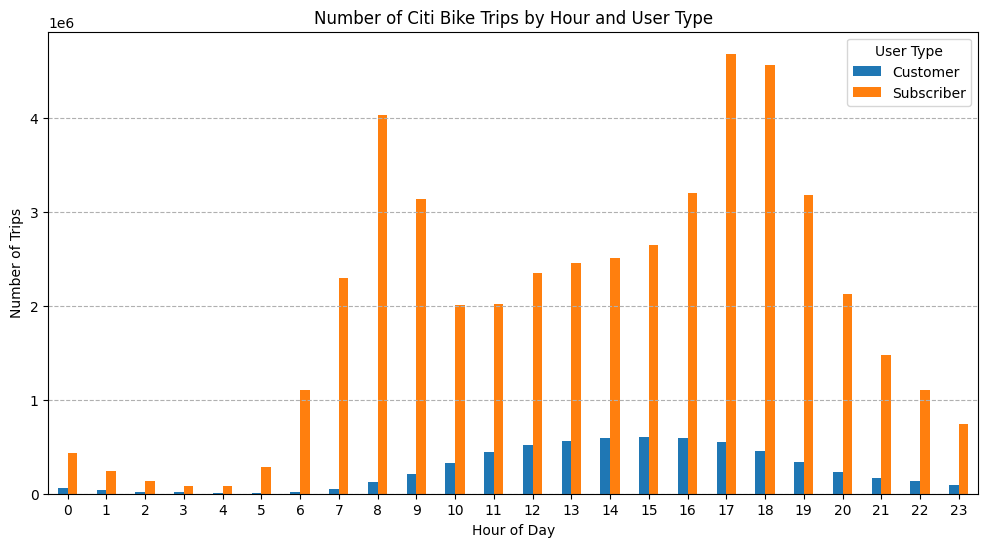

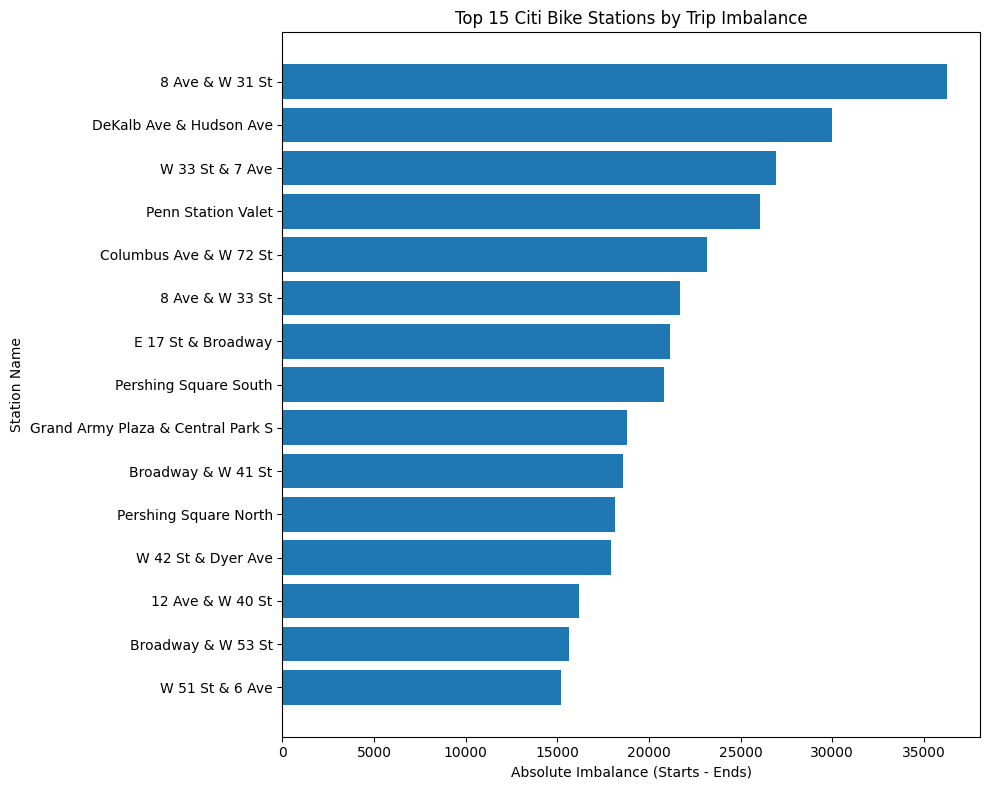

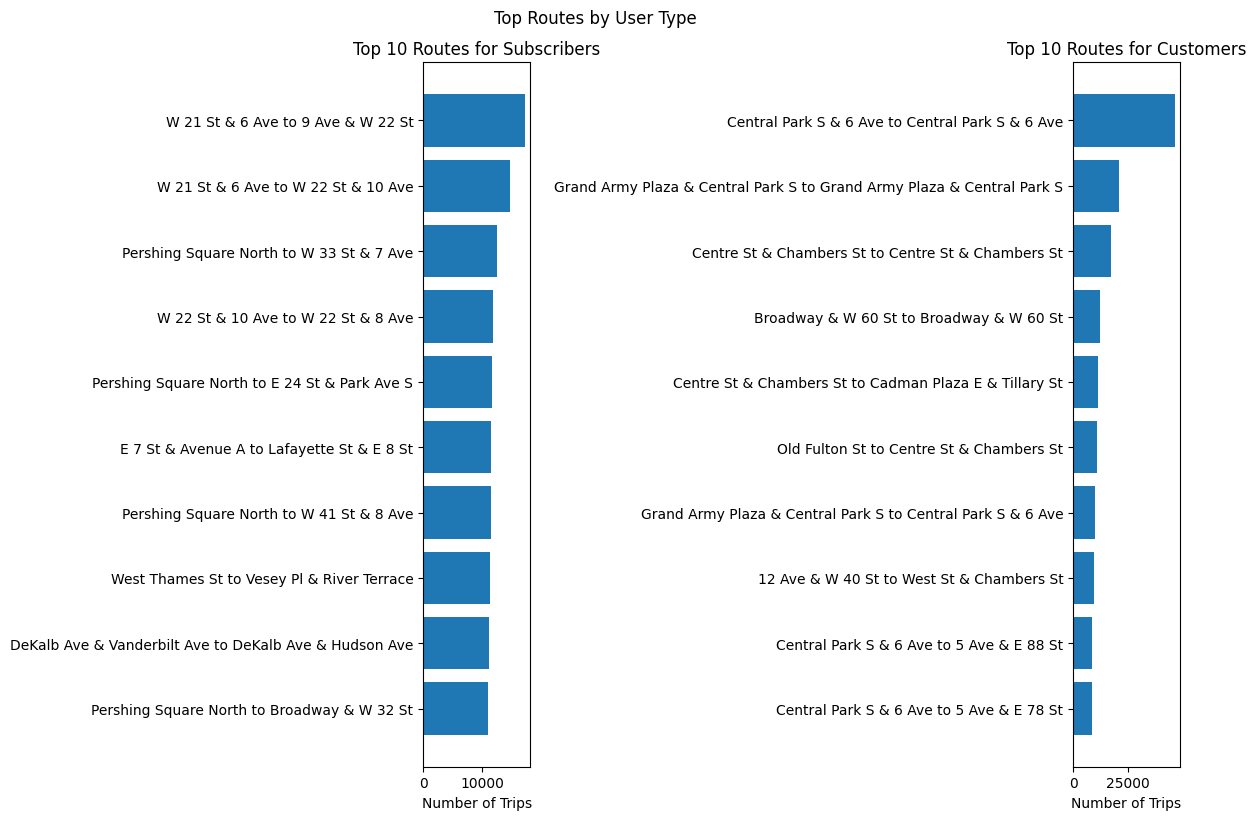

In [30]:
# Chart 1: Peak hours and user types (from df_hyp_a)
# Aggregate data to show total trips per hour and user type
pivot_hyp_a = df_hyp_a.pivot_table(index='peak_hour', columns='usertype', values='number_of_trips', aggfunc='sum').fillna(0)

pivot_hyp_a.plot(kind='bar', figsize=(12, 6))
plt.title('Number of Citi Bike Trips by Hour and User Type')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(rotation=0)
plt.legend(title='User Type')
plt.grid(axis='y', linestyle='--')
plt.show()

# Chart 2: Stations with the biggest imbalance (from df_hyp_c - using absolute_imbalance)
# Sort df_hyp_c by absolute_imbalance and take the top N
top_n = 15
top_imbalance_stations = df_hyp_c.sort_values(by='absolute_imbalance', ascending=False).head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_imbalance_stations['station_name'], top_imbalance_stations['absolute_imbalance'])
plt.xlabel('Absolute Imbalance (Starts - Ends)')
plt.ylabel('Station Name')
plt.title(f'Top {top_n} Citi Bike Stations by Trip Imbalance')
plt.gca().invert_yaxis() # Display the highest imbalance at the top
plt.tight_layout()
plt.show()

# Chart 3: Top routes by user type (from df_hyp_b)
# Separate dataframes for subscribers and customers
df_subscribers = df_hyp_b[df_hyp_b['usertype'] == 'Subscriber'].head(10)
df_customers = df_hyp_b[df_hyp_b['usertype'] == 'Customer'].head(10)

# Create route labels
df_subscribers['route'] = df_subscribers['start_station_name'] + ' to ' + df_subscribers['end_station_name']
df_customers['route'] = df_customers['start_station_name'] + ' to ' + df_customers['end_station_name']

plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1) # Subplot for Subscribers
plt.barh(df_subscribers['route'], df_subscribers['number_of_trips'])
plt.xlabel('Number of Trips')
plt.title('Top 10 Routes for Subscribers')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.subplot(1, 2, 2) # Subplot for Customers
plt.barh(df_customers['route'], df_customers['number_of_trips'])
plt.xlabel('Number of Trips')
plt.title('Top 10 Routes for Customers')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.suptitle('Top Routes by User Type', y=1.02) # Add a main title
plt.show()

## 4) KPIs & Looker Studio Dashboard
- **KPI 1:** Numer of Trips Taken During Peak Hours
- **KPI 2:** Most Frequent Routes  
- **KPI 3:** Top 10 Starting Station
- **KPI 4 (optional):** Top 10 Ending Stations  

**Dashboard Link:** https://lookerstudio.google.com/reporting/c3d7583c-83c1-4ad9-bddd-bb625be7b166   
> Ensure labels, filters, and date controls are clear for non‑technical stakeholders.

## 5) Synthesis & Recommendations
Summarize your **top 3 insights** and provide **2–3 actionable recommendations** for NYC DOT.

Insights: The first insight that I would like to point out, is the hours that are most common for people to rent the CitiBikes, you can clearly see that 8 and 9, and 5 and 6 are the most common hours. This is probably due to the people either going to work, or leaving work. Another insight that the you can see by the analysis, is that the top 10 routes are very different for customers and subscribers, there is not one overlap on the top ten routes, this provides an important insight into what is a big differnce between probably those who live in New York, and those that are tourists, and not subscribing. The final insight that I would like to point out, is the difference in top hours by custoemrs and subscribers, you can tell that it is almost inverse, where there are less subscribers using the bikes, there are more customers, which is a very intersting datapoint.

Actionable Recommendations:
1. Now knowing the distribution of peak hours and peak stations, I think that a way to maximize revenue would be to create a dynamic rebalancing strategy that would ensure sufficnet bikes are available at high-demand starting stations. I believe that having this rebalancing strategy would allow stations to be full before the peak hours begin, so that during the peak hours, they are available. I would suggest looking hypothesis C as well, so that you can focus on stations that are identified to have a high positive imbalance, more starts than finishes, during morning peak hours, and focus on the high negative imbalances, more ends, during evening peaks.
2. Another acctionable recomendation would be to add more docking stations or bikes for the routes that are most common for subscribers. If these routes are popular with subscribers, it probably means that they will continue to take these routes, to ensure that all customers have necessary bikes, we need to increase the amount of bikes that are available in those stations. For the routes that are more popular with customers, an idea could be to explore creating partnerships with local attractions and consider offering special passes or promotions for these routes, to encourage continues use.
3. The final recomendation would be depending on the imbalance of stations. For stations with a surplus (more ends), there will eventually be no docks available for incoming bikes, leading to frustration for users trying to return their bike there. So, what we could do, is encourage users to take bikes from these stations, or return their bikes to stations with defecites. I believe that this could be done through small incentives offered via the app. Similarly, for stations that a defecit (more starts), the station will quickly run out of bikes, so what I suggest, would be to ensure that bikes are moves to these stations, especially in peak hours. This would involve the operational team manually rebalancing the bikes.

## 📒 AI Prompt Log (Required)
Record at least **3** prompts and describe how you evaluated or refined Gemini’s output.

| # | Prompt (summary) | Where used | What changed after refinement? |
|---|------------------|------------|--------------------------------|
| 1 | I tried to get Gemini to help me create the SQL code for my hypothesis A testing | Hyp A | It was almost complete, but it was messing up the names of some files, which at first I did not see, only after refining and asking questions about why I got certain errors, I noticed that the table names were wrong, so I had to upload a screenshot of BigQuery, so that it could get the names correct.  |
| 2 | Similarly for hypothesis B, I asked Gemini to help me create the code for the second hypothesis testing.  | Hyp B | For hypothesis B I did not have the same problems, because the tables were already correct, however, I did have to change some of the code. Initially, the code included nulls, and because there are a lot of nulls, I had to refine my prompt to make sure that Gemini would give me the code that would exclude the null values.  |
| 3 | Again, I used Gemini to help me complete the code for my third hypothesis.  | Hyp C | Similarly to my Hypothesis B problem, this code also included the nulls, so I had to refine the prompt to make sure that nulls were left out of the code, so that I could get a more accurate picture of what was going on. |

## 📦 Appendix — Reproducibility
- BigQuery location: ☐  
- Query costs observed (if any): ☐  
- Known data quality caveats: ☐